In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from Informatics import softmax, markov_process
data = pd.read_csv("Linker dataset.csv")
tpm,amino_acids = markov_process(data)

In [10]:
olc = amino_acids
lst = list(np.random.randint(len(amino_acids),size = 10))
seq = ''
for i in lst:
    seq+=amino_acids[i]
mut = ['ins','del','sub','ret']
mutp = [1/5,1/5,1/2,1.5/5]

In [11]:
print('initial sequence : ',seq,'\n','_'*100)


initial sequence :  AQFHCPTSTP 
 ____________________________________________________________________________________________________


In [ ]:
# Algorithemic parameters
mutp = softmax(mutp)      # Probability For Different mutations
num_gen = 20              
top_k = 5
num_daughter = 1000       # Number Daughter linker samples per linker
def evolution(seq):
    out = ''
    for i in range(len(seq)):
        choice = np.random.choice(mut, p=mutp)              # Choosing the type of mutation
        if choice == 'ret':                                 # Retention - Keep the same
            out += seq[i]
        elif choice == 'del':                               # Deletion - Remove the Amino Acid
            pass
        elif choice == 'sub':                               # Substitution
            if seq[i-1]:                                    
                out += np.random.choice(olc, p=tpm[seq[i-1]])   # Choose based on Transition probability Matrix from the previous Amino acid
            else:
                out += seq[i]                                   # if first Amino acid then keep the same
        elif choice == 'ins':
            out = out + i + np.random.choice(olc, p=tpm[seq[i]]) # Choose based on Transition probability Matrix from the previous Amino acid
        else: raise ValueError('Mutation Choie error')
    return out
            
def weighted_sum(arr):
    return arr[0] +  arr[1] + arr[2] +  arr[3] +  arr[4]

In [ ]:
def pareto_dominates(parent, daughter):
    """
    Returns True if parent dominates daughter in every function aspect.
    All elements must be numeric and of the same length.
    """
    if len(parent) != len(daughter):
        raise ValueError("Vectors must have the same length")
    else:
        for i in range(len(parent)):
            if parent[i]>daughter[i]:
                return False
    return True

In [ ]:
def reward_fn(seq):
    return None

In [ ]:
k = num_gen
generation = {}
def GA(seq_l):          # Establishing the Genetic Algorithm
    global k
    global out_l2
    if k > 0:
        out_l1 = []     # Stores All daughter linkers
        out_l2 = []     # Stored all the filtered linkers
        
        k -= 1
        for i in seq_l:     
            for j in range(num_daughter):
                out_l1.append(evolution(i))
        for i in out_l1:
            if pareto_dominates(reward_fn(seq_l[0]),reward_fn(i)):      # If pareto retuns true, the linker gets appended.
                out_l2.append(i)
        out_l2.sort(key = lambda x:weighted_sum(reward_fn(x)))          # Sorting according to some weighted sum, Can use some other paramtere also
        generation[f'Generation Number {num_gen - k}'] = out_l2[:top_k]
        return GA(out_l2[:top_k])
    else:
        return out_l2
    


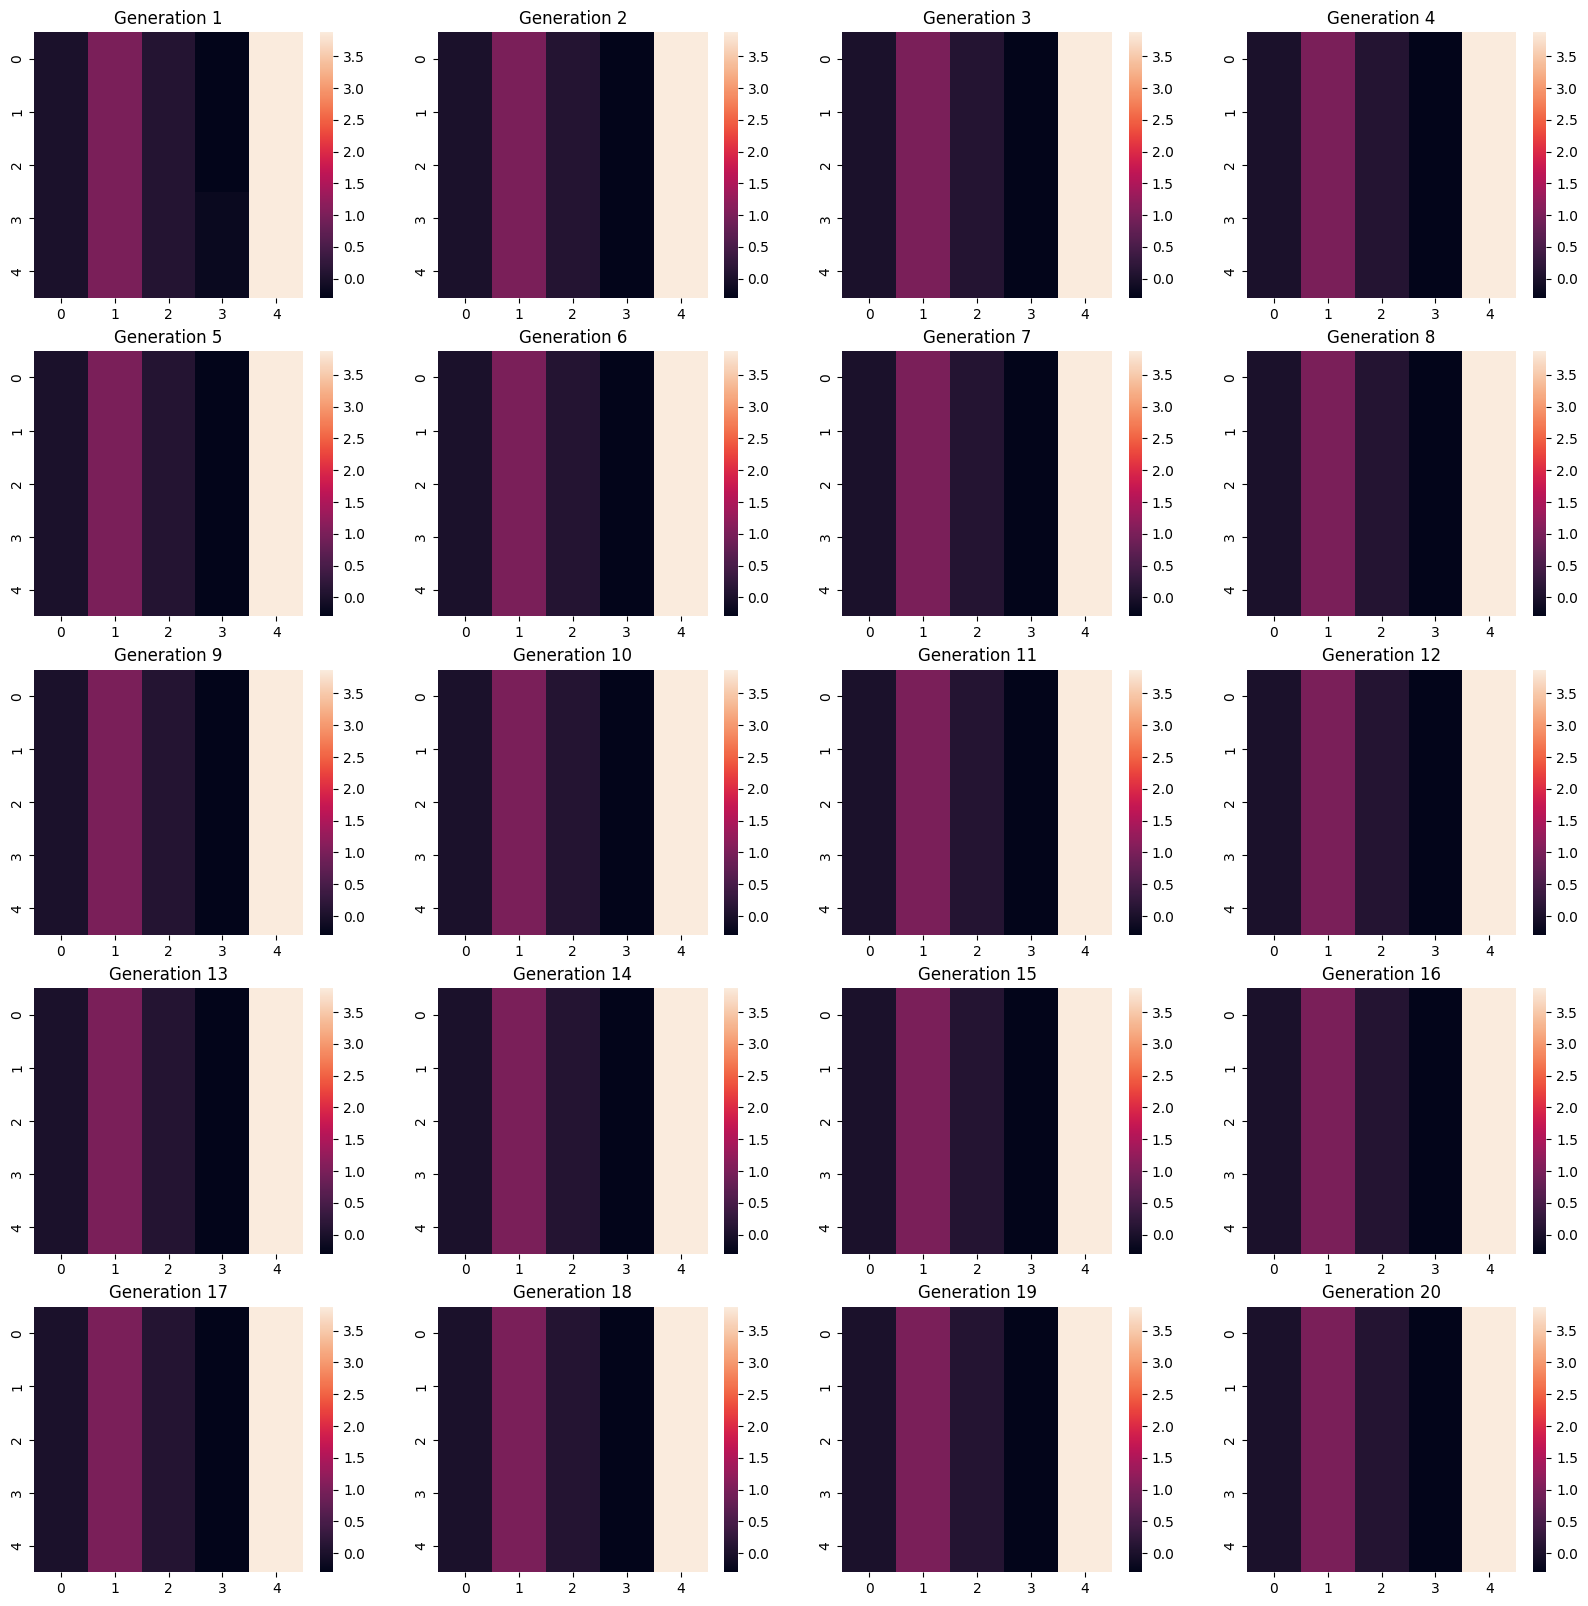

In [31]:
plt.figure(figsize=(20,20))
for i in range(1,21):
    perg = generation[f'Generation Number {i}']
    hm = np.zeros((len(perg),5))
    for j in range(len(perg)):
        hm[j] = reward_fn(perg[j])
    plt.subplot(5,4,i)
    sns.heatmap(hm)
    plt.title(f'Generation {i}')


In [ ]:

hmsl = []
for i in range(20):
    preg = generation[f'Generation Number {i+1}']
    hmsl += preg[:5]
hms = np.zeros((len(hmsl),5))
for i in range(len(hmsl)):
    hms[i] = reward_fn(hmsl[i])



Text(0, 0.5, 'Generation Progression')

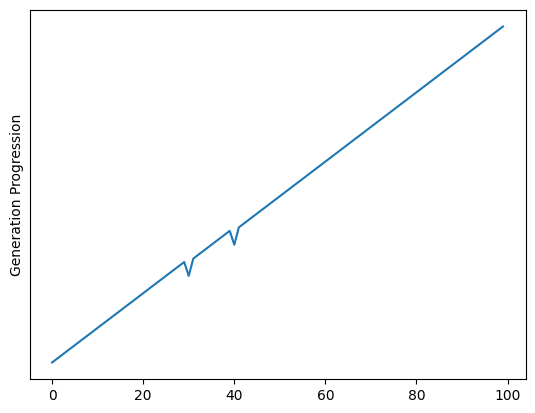

In [ ]:
plt.plot([weighted_sum(i) for i in hmsl])
plt.yticks([])
plt.ylabel('Generation Progression')

In [ ]:
#isoelectric point and Charge
import time
start = time.time()
from Bio.SeqUtils.ProtParam import ProteinAnalysis
for i in range(10):
    seq = "K"*(i+1)
    pa = ProteinAnalysis(seq)
    print(seq)
    start = time.time()
    print(pa.charge_at_pH(6.5))
    print(pa.isoelectric_point())
    end = time.time()
    print( end - start)

K
8.750052070617677
0.00032711029052734375
KK
10.002737236022949
0.00012111663818359375
KKK
10.302063941955566
0.000102996826171875
KKKK
10.477740287780762
9.965896606445312e-05
KKKKK
10.602486610412598
9.942054748535156e-05
KKKKKK
10.699318122863769
0.00010085105895996094
KKKKKKK
10.778420829772951
0.00016427040100097656
KKKKKKKK
10.845339012145995
0.00010609626770019531
KKKKKKKKK
10.903296089172361
0.00010752677917480469
KKKKKKKKKK
10.954419517517088
0.0001049041748046875


In [ ]:
pa.

9.0

In [6]:
data = pd.read_csv("C:/Users/apkar/Downloads/global_transition_matrix_readable.csv")
data

,Unnamed: 0,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,A,0.079,0.009,0.054,0.087,0.036,0.063,0.023,0.045,0.065,...,0.023,0.038,0.056,0.047,0.070,0.043,0.049,0.067,0.016,0.045
1,C,0.048,0.016,0.048,0.095,0.032,0.063,0.048,0.048,0.048,...,0.063,0.063,0.032,0.048,0.095,0.048,0.063,0.048,0.016,0.032
2,D,0.064,0.017,0.040,0.074,0.048,0.043,0.026,0.057,0.079,...,0.017,0.040,0.057,0.036,0.081,0.060,0.043,0.055,0.017,0.048
3,E,0.095,0.014,0.048,0.088,0.038,0.043,0.022,0.052,0.070,...,0.027,0.036,0.039,0.041,0.081,0.041,0.052,0.072,0.011,0.022
4,F,0.073,0.007,0.066,0.077,0.044,0.066,0.018,0.051,0.073,...,0.015,0.069,0.051,0.058,0.051,0.066,0.040,0.047,0.018,0.044
5,G,0.093,0.013,0.054,0.054,0.049,0.057,0.018,0.051,0.051,...,0.028,0.041,0.046,0.049,0.062,0.059,0.069,0.064,0.015,0.039
6,H,0.055,0.012,0.043,0.043,0.055,0.049,0.049,0.043,0.079,...,0.024,0.043,0.067,0.043,0.067,0.061,0.061,0.043,0.012,0.067
7,I,0.073,0.017,0.084,0.096,0.029,0.044,0.012,0.061,0.049,...,0.020,0.070,0.061,0.047,0.058,0.055,0.055,0.067,0.009,0.020
8,K,0.071,0.006,0.061,0.084,0.023,0.056,0.029,0.048,0.052,...,0.027,0.038,0.063,0.050,0.067,0.048,0.056,0.063,0.008,0.044
9,L,0.097,0.012,0.071,0.090,0.050,0.052,0.021,0.038,0.077,...,0.012,0.054,0.072,0.032,0.062,0.057,0.040,0.047,0.013,0.029


In [16]:
pip install pandas

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

In [2]:

data = pd.read_csv("C:/Users/apkar/Downloads/linker DB.txt",sep = '|')

<Axes: ylabel='Count'>

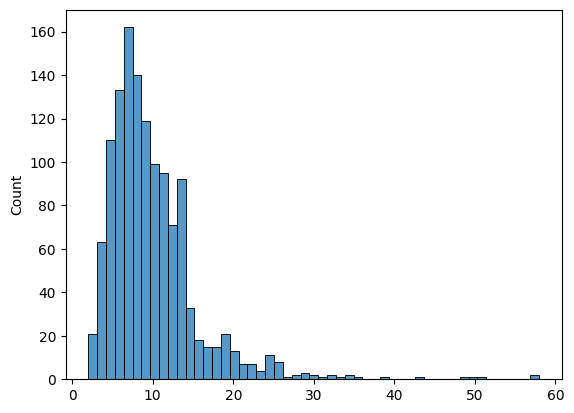

In [5]:
import seaborn as sns
sns.histplot([len(i) for i in data['GRKLWHDL']])

In [7]:
data2 = pd.read_csv("C:/Users/apkar/Downloads/linker DB2 ecoli.txt",sep = '\t')

In [8]:
data2

,1.,Q6I6B2_125_131,DEQTGEE,3.33,11.51,-1.152,ArdC protein,Unnamed: 7
0,Show details,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.,P0ADE4_84_92,RPPPKKGRQ,12.53,6.55,-1.080,TRANSLOCATION AND ASSEMBLY MODULE TAMA,NaN
2,Show details,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.,Q46731_247_255,VDKRGKRKN,11.75,5.08,-1.025,PROTEIN (TRANSPOSASE INHIBITOR PROTEIN FROM TN5),NaN
4,Show details,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
811,407.,B7L888_128_139,YIAEHVLGLPAL,5.36,14.08,0.511,ATP synthase subunit a,NaN
812,Show details,NaN,NaN,NaN,NaN,NaN,NaN,NaN
813,408.,P05041_328_341,LFVVEPFPAVHHLV,6.50,18.54,0.583,p-aminobenzoate synthase component I,NaN
814,Show details,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:


rows = []

with open("C:/Users/apkar/Downloads/linker DB2 ecoli.txt", "r") as file:
    for line in file:
        line = line.strip()
        
        # Skip empty lines or "Show details"
        if not line or "Show details" in line:
            continue
        
        # Remove numbering like "1."
        if line[0].isdigit():
            parts = line.split()
            
            row = [
                parts[1],                  # ID
                parts[2],                  # Sequence
                float(parts[3]),           # Value1
                float(parts[4]),           # Value2
                float(parts[5]),           # Score
                " ".join(parts[6:])        # Description
            ]
            rows.append(row)

# Create DataFrame
df = pd.DataFrame(rows, columns=[
    "ID", "Sequence", "Value1", "Value2", "Score", "Description"
])

print(df)

                 ID        Sequence  Value1  Value2  Score  \
0    Q6I6B2_125_131         DEQTGEE    3.33   11.51 -1.152   
1      P0ADE4_84_92       RPPPKKGRQ   12.53    6.55 -1.080   
2    Q46731_247_255       VDKRGKRKN   11.75    5.08 -1.025   
3    P0A9G8_138_144         RDHDDVQ    4.31   13.07 -0.818   
4      P76045_41_48        EGYGEDMD    3.29    7.70 -0.808   
..              ...             ...     ...     ...    ...   
403  C6FW78_191_202    APSSATVANAVG    6.10   16.84  0.443   
404    P10902_44_56   GSTFYAQGGIAAV    6.09   31.20  0.465   
405    P46003_10_22   AMCCSTGVCGTDV    3.75   11.26  0.476   
406  B7L888_128_139    YIAEHVLGLPAL    5.36   14.08  0.511   
407  P05041_328_341  LFVVEPFPAVHHLV    6.50   18.54  0.583   

                                           Description  
0                                         ArdC protein  
1               TRANSLOCATION AND ASSEMBLY MODULE TAMA  
2     PROTEIN (TRANSPOSASE INHIBITOR PROTEIN FROM TN5)  
3                          

<Axes: ylabel='Count'>

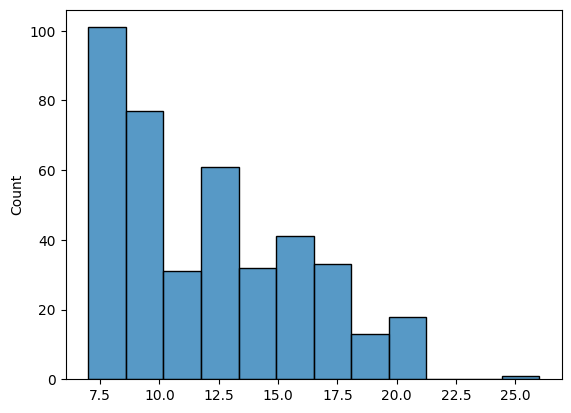

In [11]:
sns.histplot([len(i) for i in df['Sequence']])

In [1]:
import pandas as pd

In [2]:
sp = pd.read_csv("C:/Users/apkar/OneDrive/Documents/iGEM/Head/Linker design/uniprotkb_ec_3_4_21_AND_length_450_TO_5_2026_04_14 (1).tsv/uniprotkb_ec_3_4_21_AND_length_450_TO_5_2026_04_14 (1).tsv", sep = '\t')

In [29]:
len(sp)

42647

<Axes: >

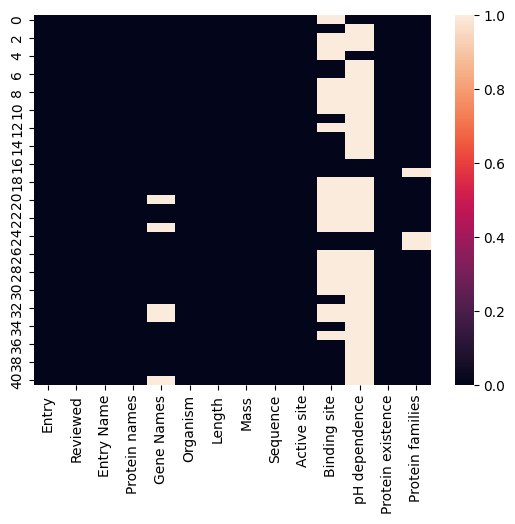

In [5]:
import seaborn as sns
sns.heatmap(sp.isnull())

In [3]:
sp

,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Mass,Sequence,Active site,Binding site,pH dependence,Protein existence,Protein families
0,O04073,reviewed,CTPA_TETOB,"C-terminal processing peptidase, chloroplastic...",ctpA D1P,Tetradesmus obliquus (Green alga) (Acutodesmus...,464,48615,MHSRTNCLQTSVRAPQPHFRPFTAVKTCRQRCSTTAAAAKRDQAQE...,"ACT_SITE 372; /note=""Charge relay system""; /ev...",NaN,BIOPHYSICOCHEMICAL PROPERTIES: pH dependence:...,Evidence at protein level,Peptidase S41A family
1,O15393,reviewed,TMPS2_HUMAN,Transmembrane protease serine 2 (EC 3.4.21.122...,TMPRSS2 PRSS10,Homo sapiens (Human),492,53859,MALNSGSPPAIGPYYENHGYQPENPYPAQPTVVPTVYEVHPAQYYP...,"ACT_SITE 296; /note=""Charge relay system""; /ev...","BINDING 131; /ligand=""Ca(2+)""; /ligand_id=""ChE...",NaN,Evidence at protein level,Peptidase S1 family
2,O35002,reviewed,CTPB_BACSU,Carboxy-terminal processing protease CtpB (C-t...,ctpB yvjB BSU35240,Bacillus subtilis (strain 168),480,52798,MNQKIMAVIAAGSMLFGGAGVYAGINLLEMDKPQTAAVPATAQADS...,"ACT_SITE 309; /note=""Nucleophile""; /evidence=""...",NaN,NaN,Evidence at protein level,Peptidase S41A family
3,O43464,reviewed,HTRA2_HUMAN,"Serine protease HTRA2, mitochondrial (EC 3.4.2...",HTRA2 OMI PRSS25,Homo sapiens (Human),458,48841,MAAPRAGRGAGWSLRAWRALGGIRWGRRPRLTPDLRALLTSGTSDP...,"ACT_SITE 198; /note=""Charge relay system""; /ev...",NaN,NaN,Evidence at protein level,Peptidase S1C family
4,O53896,reviewed,PEPD_MYCTU,Serine protease PepD (EC 3.4.21.107) (HtrA-lik...,pepD htrA2 Rv0983,Mycobacterium tuberculosis (strain ATCC 25618 ...,464,46453,MAKLARVVGLVQEEQPSDMTNHPRYSPPPQQPGTPGYAQGQQQTYS...,"ACT_SITE 197; /note=""Charge relay system""; /ev...",NaN,BIOPHYSICOCHEMICAL PROPERTIES: pH dependence:...,Evidence at protein level,Peptidase S1C family
5,P00740,reviewed,FA9_HUMAN,Coagulation factor IX (EC 3.4.21.22) (Christma...,F9,Homo sapiens (Human),461,51778,MQRVNMIMAESPGLITICLLGYLLSAECTVFLDHENANKILNRPKR...,"ACT_SITE 267; /note=""Charge relay system""; /ev...","BINDING 47; /ligand=""Ca(2+)""; /ligand_id=""ChEB...",NaN,Evidence at protein level,Peptidase S1 family
6,P00741,reviewed,FA9_BOVIN,Coagulation factor IX (EC 3.4.21.22) (Christma...,F9,Bos taurus (Bovine),462,52046,MWCLNMIMAESPGLVTICLLGYLLSAECTVFLDRENATKILHRPKR...,"ACT_SITE 268; /note=""Charge relay system""; /ev...","BINDING 47; /ligand=""Ca(2+)""; /ligand_id=""ChEB...",NaN,Evidence at protein level,Peptidase S1 family
7,P00742,reviewed,FA10_HUMAN,Coagulation factor X (EC 3.4.21.6) (Stuart fac...,F10,Homo sapiens (Human),488,54732,MGRPLHLVLLSASLAGLLLLGESLFIRREQANNILARVTRANSFLE...,"ACT_SITE 276; /note=""Charge relay system""; ACT...",NaN,NaN,Evidence at protein level,Peptidase S1 family
8,P00743,reviewed,FA10_BOVIN,Coagulation factor X (EC 3.4.21.6) (Stuart fac...,F10,Bos taurus (Bovine),492,54510,MAGLLHLVLLSTALGGLLRPAGSVFLPRDQAHRVLQRARRANSFLE...,"ACT_SITE 275; /note=""Charge relay system""; /ev...",NaN,NaN,Evidence at protein level,Peptidase S1 family
9,P00750,reviewed,TPA_HUMAN,Tissue-type plasminogen activator (t-PA) (t-pl...,PLAT,Homo sapiens (Human),562,62917,MDAMKRGLCCVLLLCGAVFVSPSQEIHARFRRGARSYQVICRDEKT...,"ACT_SITE 357; /note=""Charge relay system""; /ev...",NaN,NaN,Evidence at protein level,Peptidase S1 family


In [5]:
sp['Active site'][0]

'ACT_SITE 372; /note="Charge relay system"; /evidence="ECO:0000269|PubMed:10966643"; ACT_SITE 397; /note="Charge relay system"; /evidence="ECO:0000269|PubMed:10966643"'

In [34]:
pip install pandas requests biopython tqdm

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = sp.copy()

In [10]:
df.shape

(41, 15)

In [5]:
df["UniProt"] = df["Entry"].str.split("_").str[0]
uniprot_ids = df["UniProt"].unique().tolist()

In [6]:
import requests

def get_pdb_ids(uniprot_id):
    url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        "query": f"accession:{uniprot_id}",
        "fields": "accession,xref_pdb",
        "format": "json"
    }

    r = requests.get(url, params=params)
    data = r.json()

    try:
        xrefs = data["results"][0].get("uniProtKBCrossReferences", [])
        pdb_ids = [x["id"] for x in xrefs if x["database"] == "PDB"]
        return pdb_ids
    except:
        return []

In [8]:
import os

os.makedirs("structures", exist_ok=True)

def download_file(url, path):
    r = requests.get(url)
    if r.status_code == 200:
        with open(path, "wb") as f:
            f.write(r.content)

def fetch_structure(uniprot_id):
    pdbs = get_pdb_ids(uniprot_id)

    if pdbs and len(pdbs) > 0:
        pdb_id = pdbs[0]
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    else:
        url = f"https://alphafold.ebi.ac.uk/files/AF-{uniprot_id}-F1-model_v4.pdb"

    path = f"structures/{uniprot_id}.pdb"
    download_file(url, path)

    return path

In [9]:
from tqdm import tqdm

structure_files = {}

for uid in tqdm(uniprot_ids):
    structure_files[uid] = fetch_structure(uid)

100%|██████████| 41/41 [02:16<00:00,  3.34s/it]
